In [1]:
import mne
import numpy as np

In [2]:
from mne.brainheart.load_reference_dataset import load
raw = load()

Extracting parameters from D:\DABI\StimulationDataset\sub-4r3o\ses-postimp\ieeg\sub-4r3o_ses-postimp_task-NetworkSTIMRAWNSP2_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from D:\DABI\StimulationDataset\sub-4r3o\ses-postimp\ieeg\sub-4r3o_ses-postimp_task-NetworkSTIMRAWNSP2_run-01_events.tsv.
Reading channel info from D:\DABI\StimulationDataset\sub-4r3o\ses-postimp\ieeg\sub-4r3o_ses-postimp_task-NetworkSTIMRAWNSP2_run-01_channels.tsv.

Reading electrode coords from D:\DABI\StimulationDataset\sub-4r3o\ses-postimp\ieeg\sub-4r3o_ses-postimp_electrodes.tsv.
Reading 0 ... 1419127  =      0.000 ...   709.563 secs...


c:\Users\azhao\miniconda3\envs\mnedev\Lib\site-packages\mne_bids\read.py:720: RuntimeWarning: Channel names are not unique, found duplicates for: {'ainp2', 'ainp1'}. Applying running numbers for duplicates.
  raw.rename_channels(dict(zip(raw.ch_names, ch_names_tsv)))
C:\Users\azhao\AppData\Local\Temp\ipykernel_17784\2691673469.py:2: RuntimeWarning: Cannot set channel type for the following channels, as they are missing in the raw data: ainp1, ainp2
  raw = load()
c:\Users\azhao\miniconda3\envs\mnedev\Lib\site-packages\mne_bids\dig.py:609: RuntimeWarning: DigMontage is only a subset of info. There are 13 channel positions not present in the DigMontage. The channels missing from the montage are:

['O2 Sa', 'FZ', 'PZ', 'ainp1-0', 'ainp1-1', 'ainp1-2', 'ainp1-3', 'ainp1-4', 'ainp1-5', 'ainp1-6', 'ainp2-0', 'ainp2-1', 'ainp2-2'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if

In [18]:
tf = raw.copy().pick(np.arange(2)+63).compute_tfr(method = "morlet", freqs = np.arange(50)+30)

In [19]:
events = mne.events_from_annotations(raw)[0]
epochs = mne.Epochs(raw, events, tmin = -1, tmax = 3)
epochs.load_data()

Used Annotations descriptions: [np.str_('n/a')]
Not setting metadata
98 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 98 events and 8001 original time points ...
0 bad epochs dropped


<Epochs | 98 events (all good), -1 – 3 s (baseline -1 – 0 s), ~825.7 MiB, data loaded,
 '10001': 98>

In [22]:
tf_epochs = epochs.copy().pick(["ROF01", "ROF02"]).compute_tfr(method = "morlet", freqs = np.arange(50)+20, decim = 100)

In [21]:
raw.plot()

<module 'mne_qt_browser._pg_figure' from 'c:\\Users\\azhao\\miniconda3\\envs\\mnedev\\Lib\\site-packages\\mne_qt_browser\\_pg_figure.py'>


Channels marked as bad:
['LAV05', 'RPL01', 'RPL02', 'RPL05', 'RPL06']


In [8]:
tf.data.shape

(2, 20, 1419128)

In [23]:
tf_epochs.freqs

array([20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.,
       33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43., 44., 45.,
       46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56., 57., 58.,
       59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.])

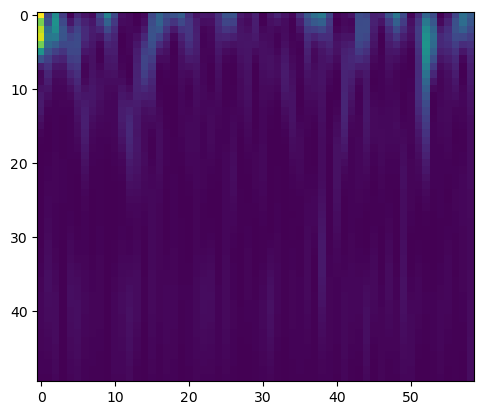

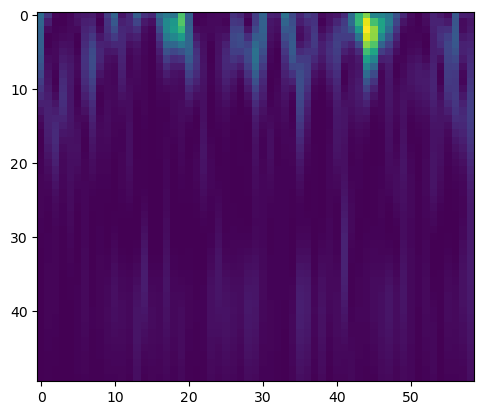

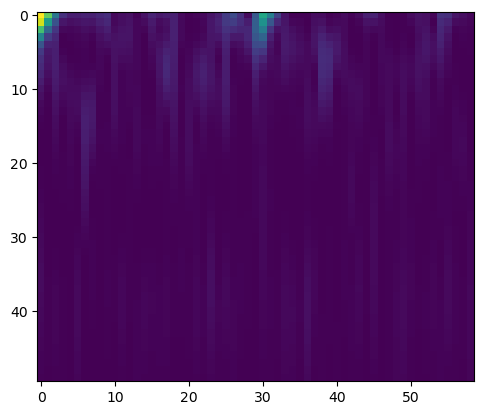

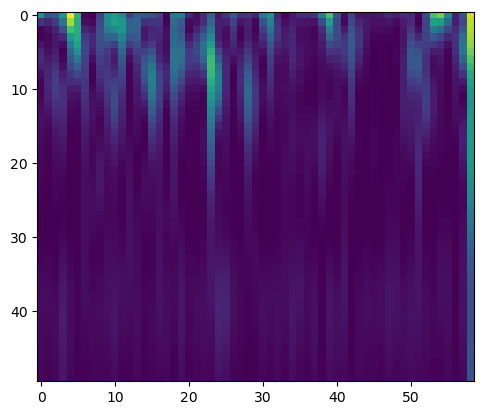

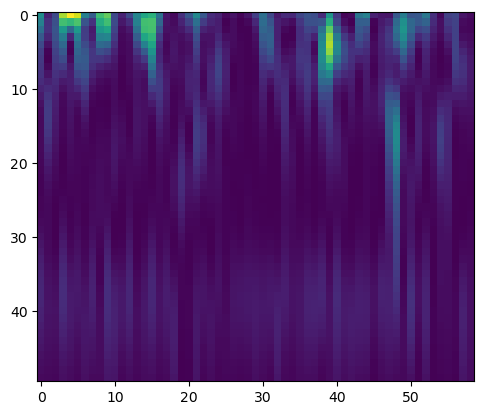

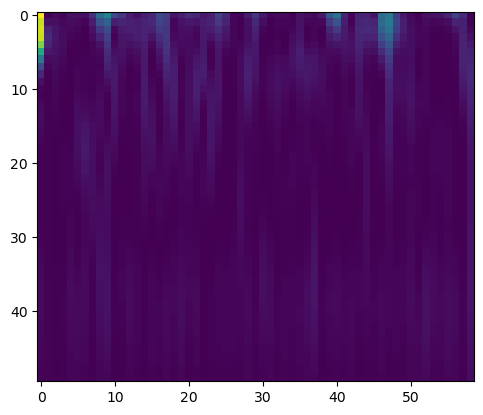

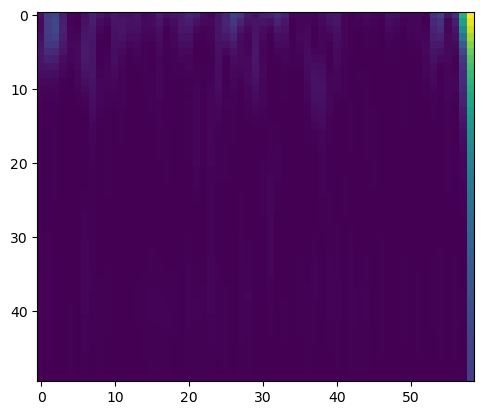

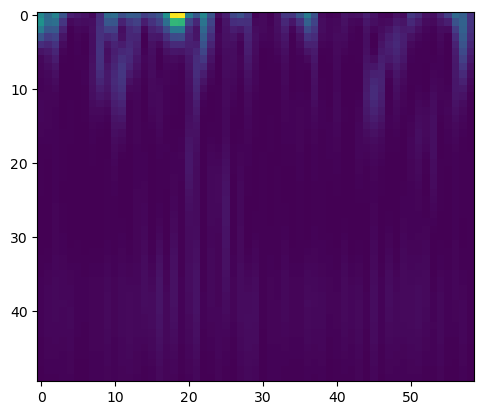

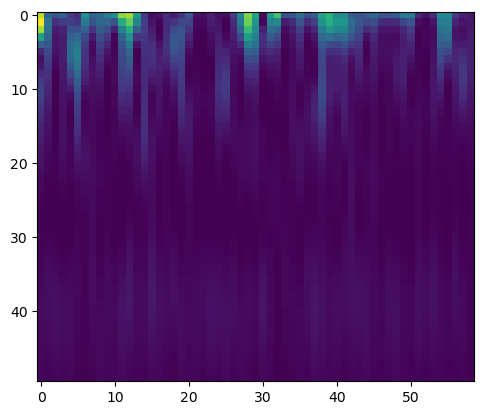

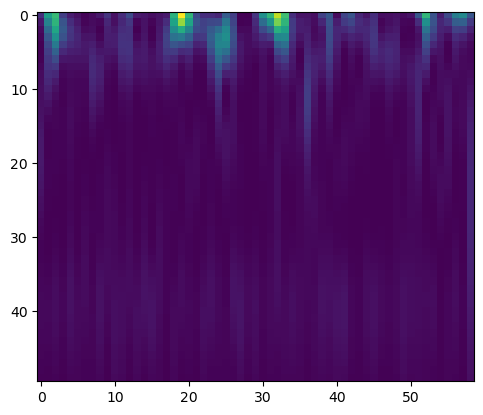

In [37]:
import matplotlib.pyplot as plt

for i in range(20, 30):
    data = tf_epochs.data[i, 0, :, 22:]
    plt.imshow(np.abs(data))
    plt.show()

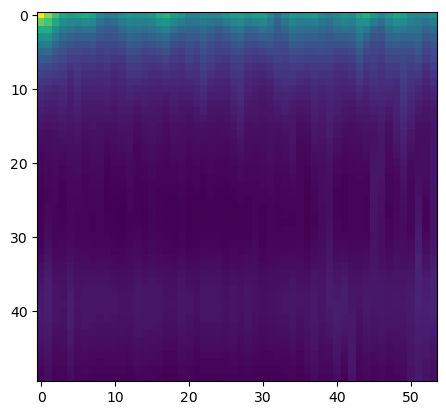

In [45]:
data = evoked.data
plt.imshow(data[0, :, 24:-3])

No baseline correction applied


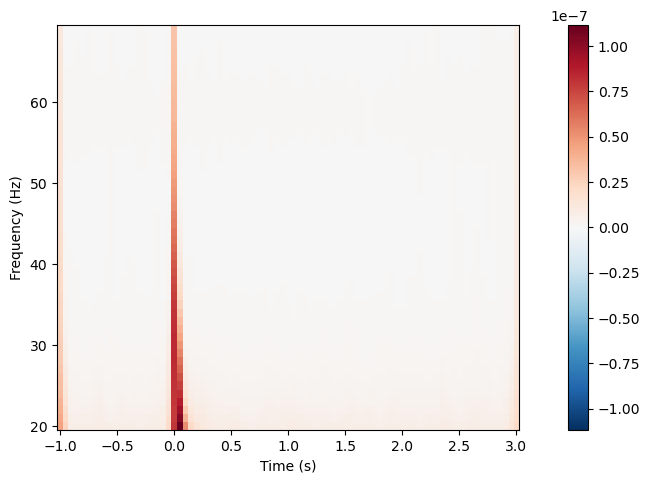

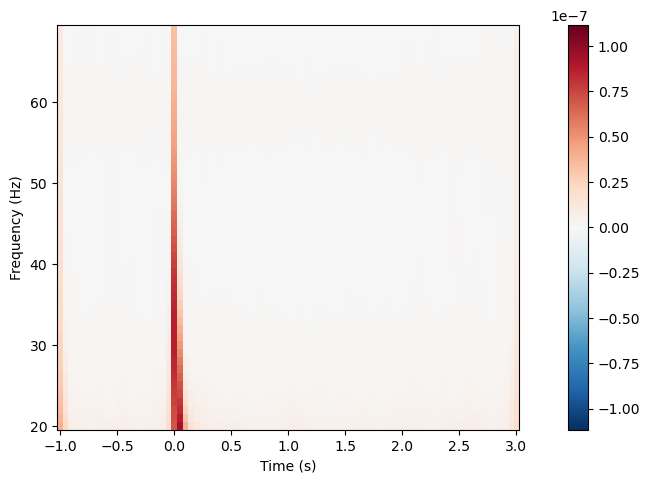

[<Figure size 640x480 with 2 Axes>, <Figure size 640x480 with 2 Axes>]

In [29]:
evoked = tf_epochs.average()
evoked.plot()